In [3]:
!pip install kagglehub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.3/68.3 kB 3.0 MB/s eta 0:00:00


In [7]:
import pandas as pd
import numpy as np

In [5]:
import kagglehub

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

In [26]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [8]:
# Download latest version
path = kagglehub.dataset_download("uom190346a/e-commerce-customer-behavior-dataset")

print("Path to dataset files:", path)

100%|███████████████████████████████████████| 2.84k/2.84k [00:00<00:00, 368kB/s]

Extracting files...
Path to dataset files: /Users/yuliaklyushina/.cache/kagglehub/datasets/uom190346a/e-commerce-customer-behavior-dataset/versions/1


In [12]:
df = pd.read_csv('/Users/yuliaklyushina/Desktop/E-commerce Customer Behavior - Sheet1.csv')

In [13]:
df.head()

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,101,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied
1,102,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied
3,104,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,Satisfied
4,105,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               350 non-null    int64  
 1   Gender                    350 non-null    object 
 2   Age                       350 non-null    int64  
 3   City                      350 non-null    object 
 4   Membership Type           350 non-null    object 
 5   Total Spend               350 non-null    float64
 6   Items Purchased           350 non-null    int64  
 7   Average Rating            350 non-null    float64
 8   Discount Applied          350 non-null    bool   
 9   Days Since Last Purchase  350 non-null    int64  
 10  Satisfaction Level        348 non-null    object 
dtypes: bool(1), float64(2), int64(4), object(4)
memory usage: 27.8+ KB


In [16]:
df.isna().sum()
df.describe(include='all')

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
count,350.000000,350,350.000000,350,350,350.000000,350.000000,350.000000,350,350.000000,348
unique,NaN,2,NaN,6,3,NaN,NaN,NaN,2,NaN,3
top,NaN,Female,NaN,New York,Gold,NaN,NaN,NaN,True,NaN,Satisfied
freq,NaN,175,NaN,59,117,NaN,NaN,NaN,175,NaN,125
mean,275.500000,NaN,33.597143,NaN,NaN,845.381714,12.600000,4.019143,NaN,26.588571,NaN
std,101.180532,NaN,4.870882,NaN,NaN,362.058695,4.155984,0.580539,NaN,13.440813,NaN
min,101.000000,NaN,26.000000,NaN,NaN,410.800000,7.000000,3.000000,NaN,9.000000,NaN
25%,188.250000,NaN,30.000000,NaN,NaN,502.000000,9.000000,3.500000,NaN,15.000000,NaN
50%,275.500000,NaN,32.500000,NaN,NaN,775.200000,12.000000,4.100000,NaN,23.000000,NaN
75%,362.750000,NaN,37.000000,NaN,NaN,1160.600000,15.000000,4.500000,NaN,38.000000,NaN


In [20]:
df['Satisfaction Level'] = df['Satisfaction Level'].fillna(df['Satisfaction Level'].mode()[0], inplace=True)


In [21]:
rfm = df[['Customer ID', 'Total Spend', 'Items Purchased', 'Days Since Last Purchase']].copy()
rfm.columns = ['CustomerID', 'monetary', 'frequency', 'recency']
rfm.head()

,CustomerID,monetary,frequency,recency
0,101,1120.20,14,25
1,102,780.50,11,18
2,103,510.75,9,42
3,104,1480.30,19,12
4,105,720.40,13,55


In [23]:
#Preprocessing (Scaling + Logarithm)
from scipy.stats.mstats import winsorize
from sklearn.preprocessing import StandardScaler
X = rfm[['recency', 'frequency', 'monetary']].copy()

# Trim the tails (to prevent extreme values ​​from having an influence)
X['recency'] = winsorize(X['recency'], limits=[0, 0.02])
X['frequency'] = winsorize(X['frequency'], limits=[0, 0.02])
X['monetary'] = winsorize(X['monetary'], limits=[0, 0.02])

# Logarithm, except for recency
X['frequency'] = np.log1p(X['frequency'])
X['monetary'] = np.log1p(X['monetary'])

# Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [24]:
#Selecting the Number of Clusters (Elbow Method)

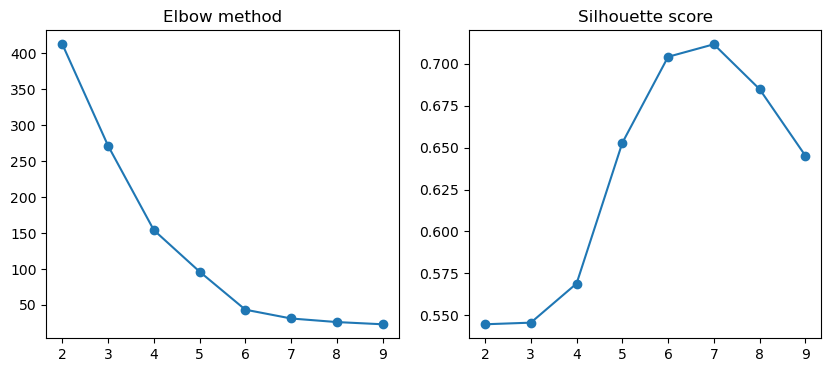

In [28]:
inertias, sil_scores = [], []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, kmeans.labels_))

fig, ax = plt.subplots(1,2, figsize=(10,4))
ax[0].plot(K, inertias, marker='o'); ax[0].set_title('Elbow method')
ax[1].plot(K, sil_scores, marker='o'); ax[1].set_title('Silhouette score')
plt.show()


In [30]:
#Train a model with k=6 (Customer Clustering):
kmeans = KMeans(n_clusters=6, random_state=42, n_init=50)
rfm['cluster'] = kmeans.fit_predict(X_scaled)
rfm.head(10)

,CustomerID,monetary,frequency,recency,cluster
0,101,1120.20,14,25,2
1,102,780.50,11,18,4
2,103,510.75,9,42,3
3,104,1480.30,19,12,1
4,105,720.40,13,55,5
5,106,440.80,8,22,0
6,107,1150.60,15,28,2
7,108,800.90,12,14,4
8,109,495.25,10,40,3
9,110,1520.10,21,9,1


In [32]:
#Average RFM values by cluster:
cluster_profile = rfm.groupby('cluster')[['recency','frequency','monetary']].mean().round(2)
display(cluster_profile)

,recency,frequency,monetary
cluster,,,
0,22.76,7.57,446.89
1,11.17,20.00,1459.77
2,24.59,15.27,1165.04
3,38.76,9.60,550.13
4,15.27,11.68,805.49
5,53.18,12.76,703.69


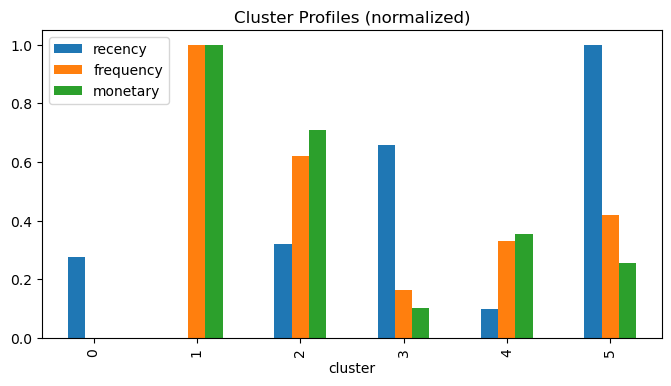

In [33]:
#Visualize Segment Profiles:
cluster_profile_norm = (cluster_profile - cluster_profile.min()) / (cluster_profile.max() - cluster_profile.min())
cluster_profile_norm.plot(kind='bar', figsize=(8,4), title='Cluster Profiles (normalized)')
plt.show()


In [36]:
#train/test separation and Random Forest training
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, rfm['cluster'], test_size=0.2, random_state=42, stratify=rfm['cluster']
)

rf = RandomForestClassifier(n_estimators=400, random_state=42, class_weight='balanced_subsample')
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred))



              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00        12
           3       1.00      1.00      1.00        16
           4       1.00      1.00      1.00        12
           5       1.00      1.00      1.00         7

    accuracy                           1.00        70
   macro avg       1.00      1.00      1.00        70
weighted avg       1.00      1.00      1.00        70



In [38]:
pd.DataFrame(confusion_matrix(y_test, y_pred),
             index=[f'True_{i}' for i in range(6)],
             columns=[f'Pred_{i}' for i in range(6)])

,Pred_0,Pred_1,Pred_2,Pred_3,Pred_4,Pred_5
True_0,12,0,0,0,0,0
True_1,0,11,0,0,0,0
True_2,0,0,12,0,0,0
True_3,0,0,0,16,0,0
True_4,0,0,0,0,12,0
True_5,0,0,0,0,0,7
